## Plot function for "Isolate Label Skew Effects"

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_label_skew_metric(
    csv_path,
    metric="f1_global_macro",
    beta_q=10.0,
    save_path=None,
):
    """
    Plot performance as a function of beta_L while keeping beta_Q fixed.

    Parameters
    ----------
    csv_path : str
        Path to the summary csv.
    metric : str
        One of:
        - "f1_global_macro"
        - "f1_per_client_macro"
        - "mse_macro"
        - "ece_macro"
    beta_q : float
        Fixed beta_Q value used to isolate label skew effects.
    save_path : str or None
        Optional path to save the figure.
    """

    df = pd.read_csv(csv_path)

    # Filter to isolate label skew effects
    df = df[df["beta_Q"] == beta_q].copy()

    if df.empty:
        raise ValueError(f"No rows found with beta_Q = {beta_q}")

    metric_map = {
        "f1_global_macro": [
            "F1_global_AlveolarOsteitis",
            "F1_global_SecondaryInfection",
            "F1_global_NerveDysesthesia",
            "F1_global_Bleeding",
        ],
        "f1_per_client_macro": [
            "F1_per_client_AlveolarOsteitis",
            "F1_per_client_SecondaryInfection",
            "F1_per_client_NerveDysesthesia",
            "F1_per_client_Bleeding",
        ],
        "mse_macro": [
            "MSE_AlveolarOsteitis",
            "MSE_SecondaryInfection",
            "MSE_NerveDysesthesia",
            "MSE_Bleeding",
        ],
        "ece_macro": [
            "ECE_AlveolarOsteitis",
            "ECE_SecondaryInfection",
            "ECE_NerveDysesthesia",
            "ECE_Bleeding",
        ],
    }

    if metric not in metric_map:
        raise ValueError(
            f"Unknown metric '{metric}'. Choose one of: {list(metric_map.keys())}"
        )

    cols = metric_map[metric]

    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in csv: {missing}")

    # Macro average across complications
    df["plot_metric"] = df[cols].mean(axis=1)

    # Sort values for clean plotting
    df = df.sort_values(["paradigm", "beta_L"])

    ylabel_map = {
        "f1_global_macro": "Macro F1 (global)",
        "f1_per_client_macro": "Macro F1 (per client)",
        "mse_macro": "Macro MSE",
        "ece_macro": "Macro ECE",
    }

    #print(df[df["paradigm"]=="local"][["beta_L","plot_metric"]])
    #print(df[df["paradigm"]=="centralized"][["beta_L","plot_metric"]])
    plt.figure(figsize=(8, 5))

    for paradigm in df["paradigm"].dropna().unique():
        sub = df[df["paradigm"] == paradigm].sort_values("beta_L")
        plt.plot(sub["beta_L"], sub["plot_metric"], marker="o", label=paradigm)

    plt.xlabel(r"Label skew $\beta_L$")
    plt.ylabel(ylabel_map[metric])
    plt.title(f"{ylabel_map[metric]} vs. $\\beta_L$ (with $\\beta_Q={beta_q}$)")
    plt.legend(title="Paradigm")
    plt.grid(True)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

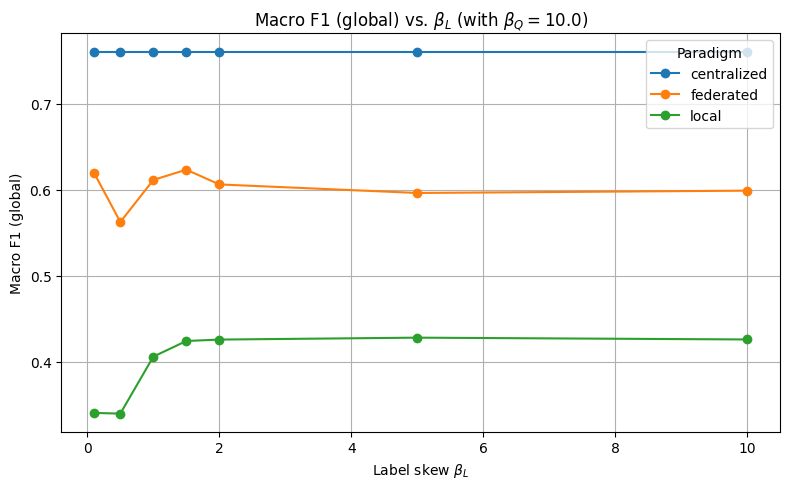

In [16]:
csv_path = r"C:\Users\oskar\OneDrive\Desktop\4 Semester\Dataproject\Federated-dental-risk-vol2\federated-dental-risk-prediction\src\fdrp\analysis\Results\sweep_beta_summary_1.csv"
plot_label_skew_metric(csv_path, metric="f1_global_macro", beta_q=10.0)

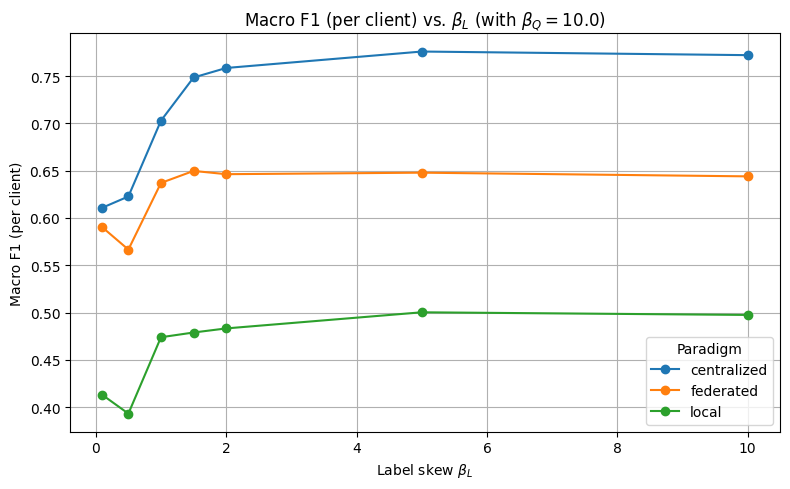

In [11]:
plot_label_skew_metric(csv_path, metric="f1_per_client_macro", beta_q=10.0)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_quantity_skew_metric(
    csv_path,
    metric="f1_global_macro",
    beta_l=10.0,
    save_path=None,
):
    """
    Plot performance as a function of beta_Q while keeping beta_L fixed.

    Parameters
    ----------
    csv_path : str
        Path to the summary csv.
    metric : str
        One of:
        - "f1_global_macro"
        - "f1_per_client_macro"
        - "mse_macro"
        - "ece_macro"
    beta_l : float
        Fixed beta_L value used to isolate quantity skew effects.
    save_path : str or None
        Optional path to save the figure.
    """

    df = pd.read_csv(csv_path)

    # Filter to isolate quantity skew effects
    df = df[df["beta_L"] == beta_l].copy()

    if df.empty:
        raise ValueError(f"No rows found with beta_L = {beta_l}")

    allowed_metrics = [
        "f1_global_macro",
        "f1_per_client_macro",
        "mse_macro",
        "ece_macro",
    ]

    if metric not in allowed_metrics:
        raise ValueError(
            f"Unknown metric '{metric}'. Choose one of: {allowed_metrics}"
        )

    if metric not in df.columns:
        raise ValueError(f"Column '{metric}' not found in csv")

    # Sort values for clean plotting
    df = df.sort_values(["paradigm", "beta_Q"])

    ylabel_map = {
        "f1_global_macro": "Macro F1 (global)",
        "f1_per_client_macro": "Macro F1 (per client)",
        "mse_macro": "Macro MSE",
        "ece_macro": "Macro ECE",
    }

    plt.figure(figsize=(8, 5))

    for paradigm in df["paradigm"].dropna().unique():
        sub = df[df["paradigm"] == paradigm].sort_values("beta_Q")
        plt.plot(sub["beta_Q"], sub[metric], marker="o", label=paradigm)

    plt.xlabel(r"Quantity skew $\beta_Q$")
    plt.ylabel(ylabel_map[metric])
    plt.title(f"{ylabel_map[metric]} vs. $\\beta_Q$ (with $\\beta_L={beta_l}$)")
    plt.legend(title="Paradigm")
    plt.grid(True)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

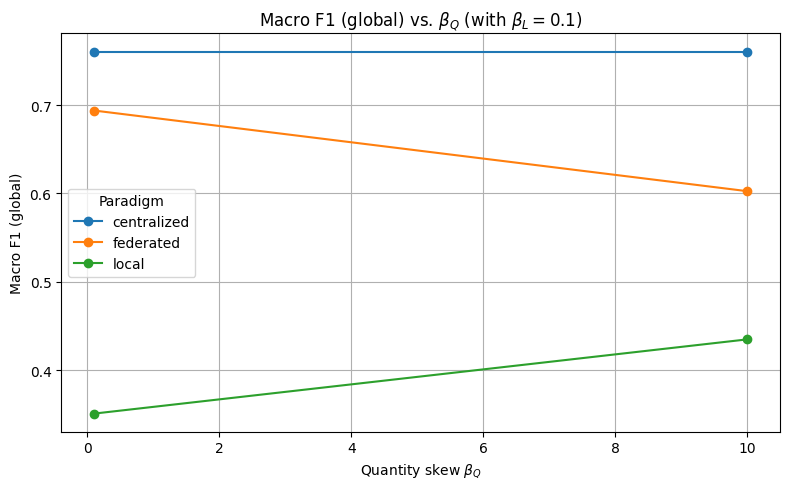

In [4]:
csv_path_test = r"C:\Users\oskar\OneDrive\Desktop\4 Semester\Dataproject\Federated-dental-risk-vol2\federated-dental-risk-prediction\src\fdrp\analysis\Results\sweep_beta_summary.csv"
plot_quantity_skew_metric(
    csv_path=csv_path_test,
    metric="f1_global_macro",
    beta_l=0.1
)

In [6]:
import pandas as pd

df = pd.read_csv(csv_path_test)

df

,paradigm,beta_L,beta_Q,seed,f1_global_macro,f1_per_client_macro,mse_macro,ece_macro,MSE_AlveolarOsteitis,ECE_AlveolarOsteitis,...,F1_global_SecondaryInfection,F1_per_client_SecondaryInfection,F1_global_NerveDysesthesia,F1_per_client_NerveDysesthesia,F1_global_Bleeding,F1_per_client_Bleeding,disagreement_per_client_macro,disagreement_global_macro,fleiss_kappa_per_client_macro,fleiss_kappa_global_macro
0,centralized,0.1,0.1,42,0.760533,0.762452,0.000296,0.002131,0.000672,0.003536,...,0.824621,0.807215,0.650150,0.728516,0.735156,0.704900,0.265583,0.000000,0.865729,1.000000
1,local,0.1,0.1,42,0.350642,0.440849,0.075797,0.190790,0.064514,0.174966,...,0.410488,0.493526,0.252439,0.386914,0.334682,0.411527,0.998250,0.887833,0.186753,0.127586
2,federated,0.1,0.1,42,0.693773,0.719854,0.000454,0.004673,0.001078,0.010358,...,0.776181,0.768690,0.548171,0.667895,0.674102,0.666057,0.433500,0.000000,0.814736,1.000000
3,centralized,0.1,10.0,42,0.760533,0.781927,0.000296,0.002131,0.000672,0.003536,...,0.824621,0.823964,0.650150,0.747623,0.735156,0.724441,0.091250,0.000000,0.958024,1.000000
4,local,0.1,10.0,42,0.434694,0.509165,0.001113,0.004488,0.002235,0.007571,...,0.500091,0.626055,0.295309,0.379224,0.351768,0.405818,0.898333,0.902250,0.372550,0.372677
5,federated,0.1,10.0,42,0.602450,0.650304,0.000547,0.001793,0.001154,0.002114,...,0.733973,0.751591,0.357142,0.517733,0.560283,0.576236,0.089917,0.000000,0.958248,1.000000


In [3]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_mu_sweep(
    csv_path,
    metric="f1_global_macro",
    save_path=None,
):
    """
    Plot performance vs FedProx μ with centralized and local baselines.
    """

    df = pd.read_csv(csv_path)

    plt.figure(figsize=(7,5))

    # -------- Federated curve --------
    df_fed = df[df["paradigm"] == "federated"].copy()
    df_fed = df_fed.sort_values("fedprox_mu")

    mu_vals = df_fed["fedprox_mu"]
    metric_vals = df_fed[metric]

    plt.plot(
        mu_vals,
        metric_vals,
        marker="o",
        linewidth=2,
        label="Federated (FedAvg/FedProx)"
    )

    # -------- Centralized baseline --------
    df_cent = df[df["paradigm"] == "centralized"]
    if not df_cent.empty:
        val = df_cent.iloc[0][metric]
        plt.axhline(
            val,
            linestyle="--",
            label="Centralized"
        )

    # -------- Local baseline --------
    df_local = df[df["paradigm"] == "local"]
    if not df_local.empty:
        val = df_local.iloc[0][metric]
        plt.axhline(
            val,
            linestyle=":",
            label="Local"
        )

    # -------- FedAvg marker --------
    fedavg_row = df_fed[df_fed["fedprox_mu"] == 0.0]
    if not fedavg_row.empty:
        fedavg_val = fedavg_row.iloc[0][metric]
        plt.scatter(
            [0.0],
            [fedavg_val],
            s=80,
            label="FedAvg (μ=0)"
        )

    plt.xscale("log")
    plt.xlabel("FedProx μ (log scale)")
    plt.ylabel(metric)
    plt.title(f"{metric} vs FedProx μ")

    plt.grid(True)
    plt.legend()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

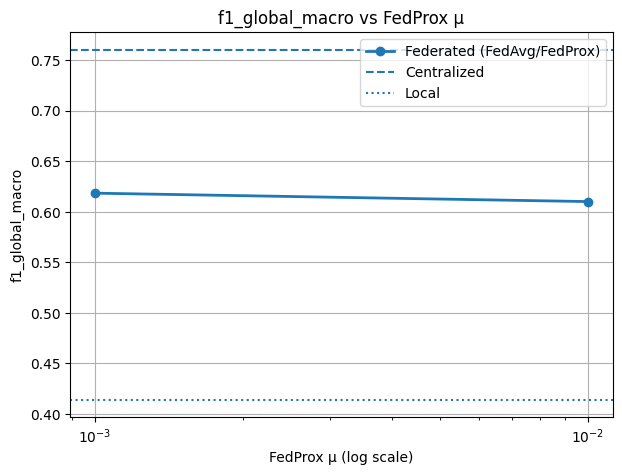

In [4]:
csv_path_mu = r"C:\Users\oskar\OneDrive\Desktop\4 Semester\Dataproject\Federated-dental-risk-vol2\federated-dental-risk-prediction\src\fdrp\analysis\Results\fedprox_mu_sweep_summary_test.csv"
plot_mu_sweep(
    csv_path=csv_path_mu,
    metric="f1_global_macro"
)